# Task 1: Exploratory Data Analysis (EDA)
This notebook covers the initial exploratory analysis of the financial news dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.feature_extraction.text import CountVectorizer

# Load data
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()

,headline,url,publisher,date,stock
0,Tech stocks lead gains in afternoon trading,https://example.com/article/0,Bloomberg,2023-01-29 05:00:00,TSLA
1,Tech stocks lead gains in afternoon trading,https://example.com/article/1,CNBC,2023-01-02 18:00:00,MSFT
2,Market rallies on news of lower interest rates,https://example.com/article/2,Reuters,2023-01-12 07:00:00,TSLA
3,Tech stocks lead gains in afternoon trading,https://example.com/article/3,The Motley Fool,2023-01-22 10:00:00,AMZN
4,AAPL to launch new wearable device next month,https://example.com/article/4,Seeking Alpha,2023-01-20 16:00:00,MSFT


## 1. Headline Length Analysis

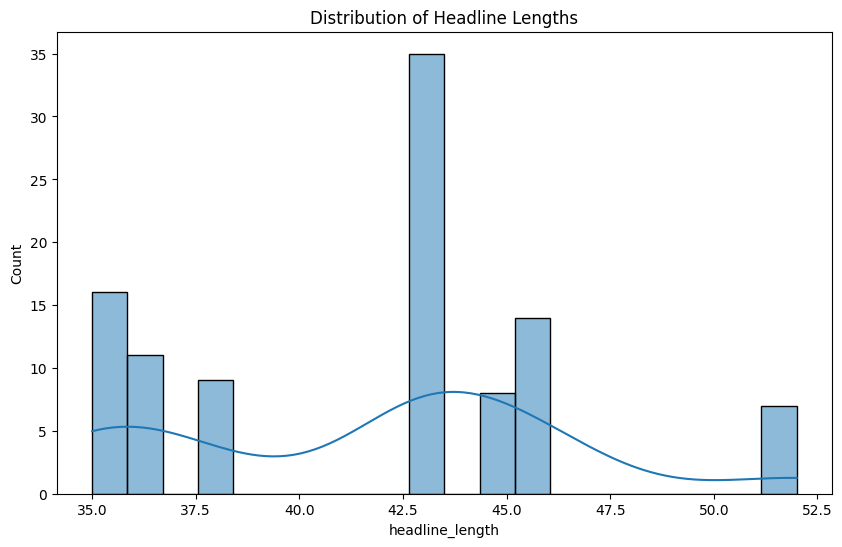

In [2]:
df['headline_length'] = df['headline'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_length'], bins=20, kde=True)
plt.title('Distribution of Headline Lengths')
plt.show()

## 2. Publisher Activity

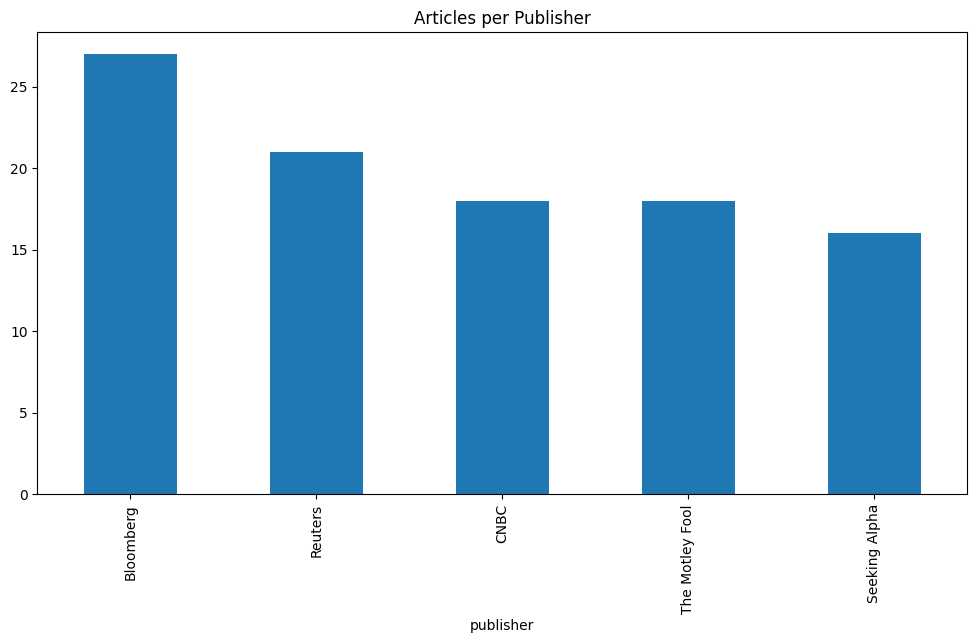

In [3]:
df['publisher'].value_counts().plot(kind='bar', figsize=(12, 6))
plt.title('Articles per Publisher')
plt.show()

## 3. Topic Modeling (Keyword Extraction)

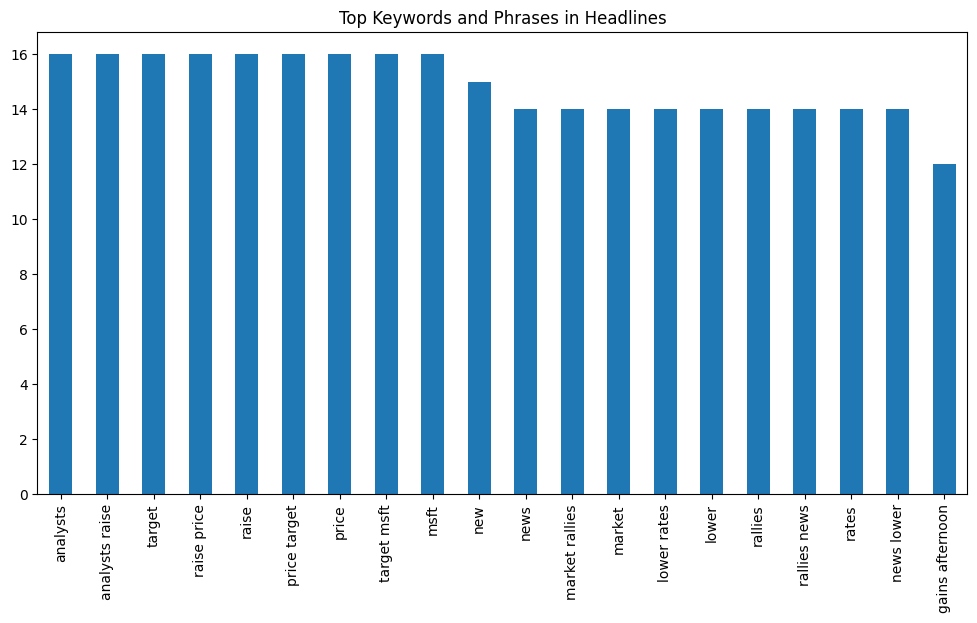

In [4]:
vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=20)
X = vectorizer.fit_transform(df['headline'])
keywords = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out()).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
keywords.plot(kind='bar')
plt.title('Top Keywords and Phrases in Headlines')
plt.show()